<a href="https://colab.research.google.com/github/tanusha-06/DS_Project1/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

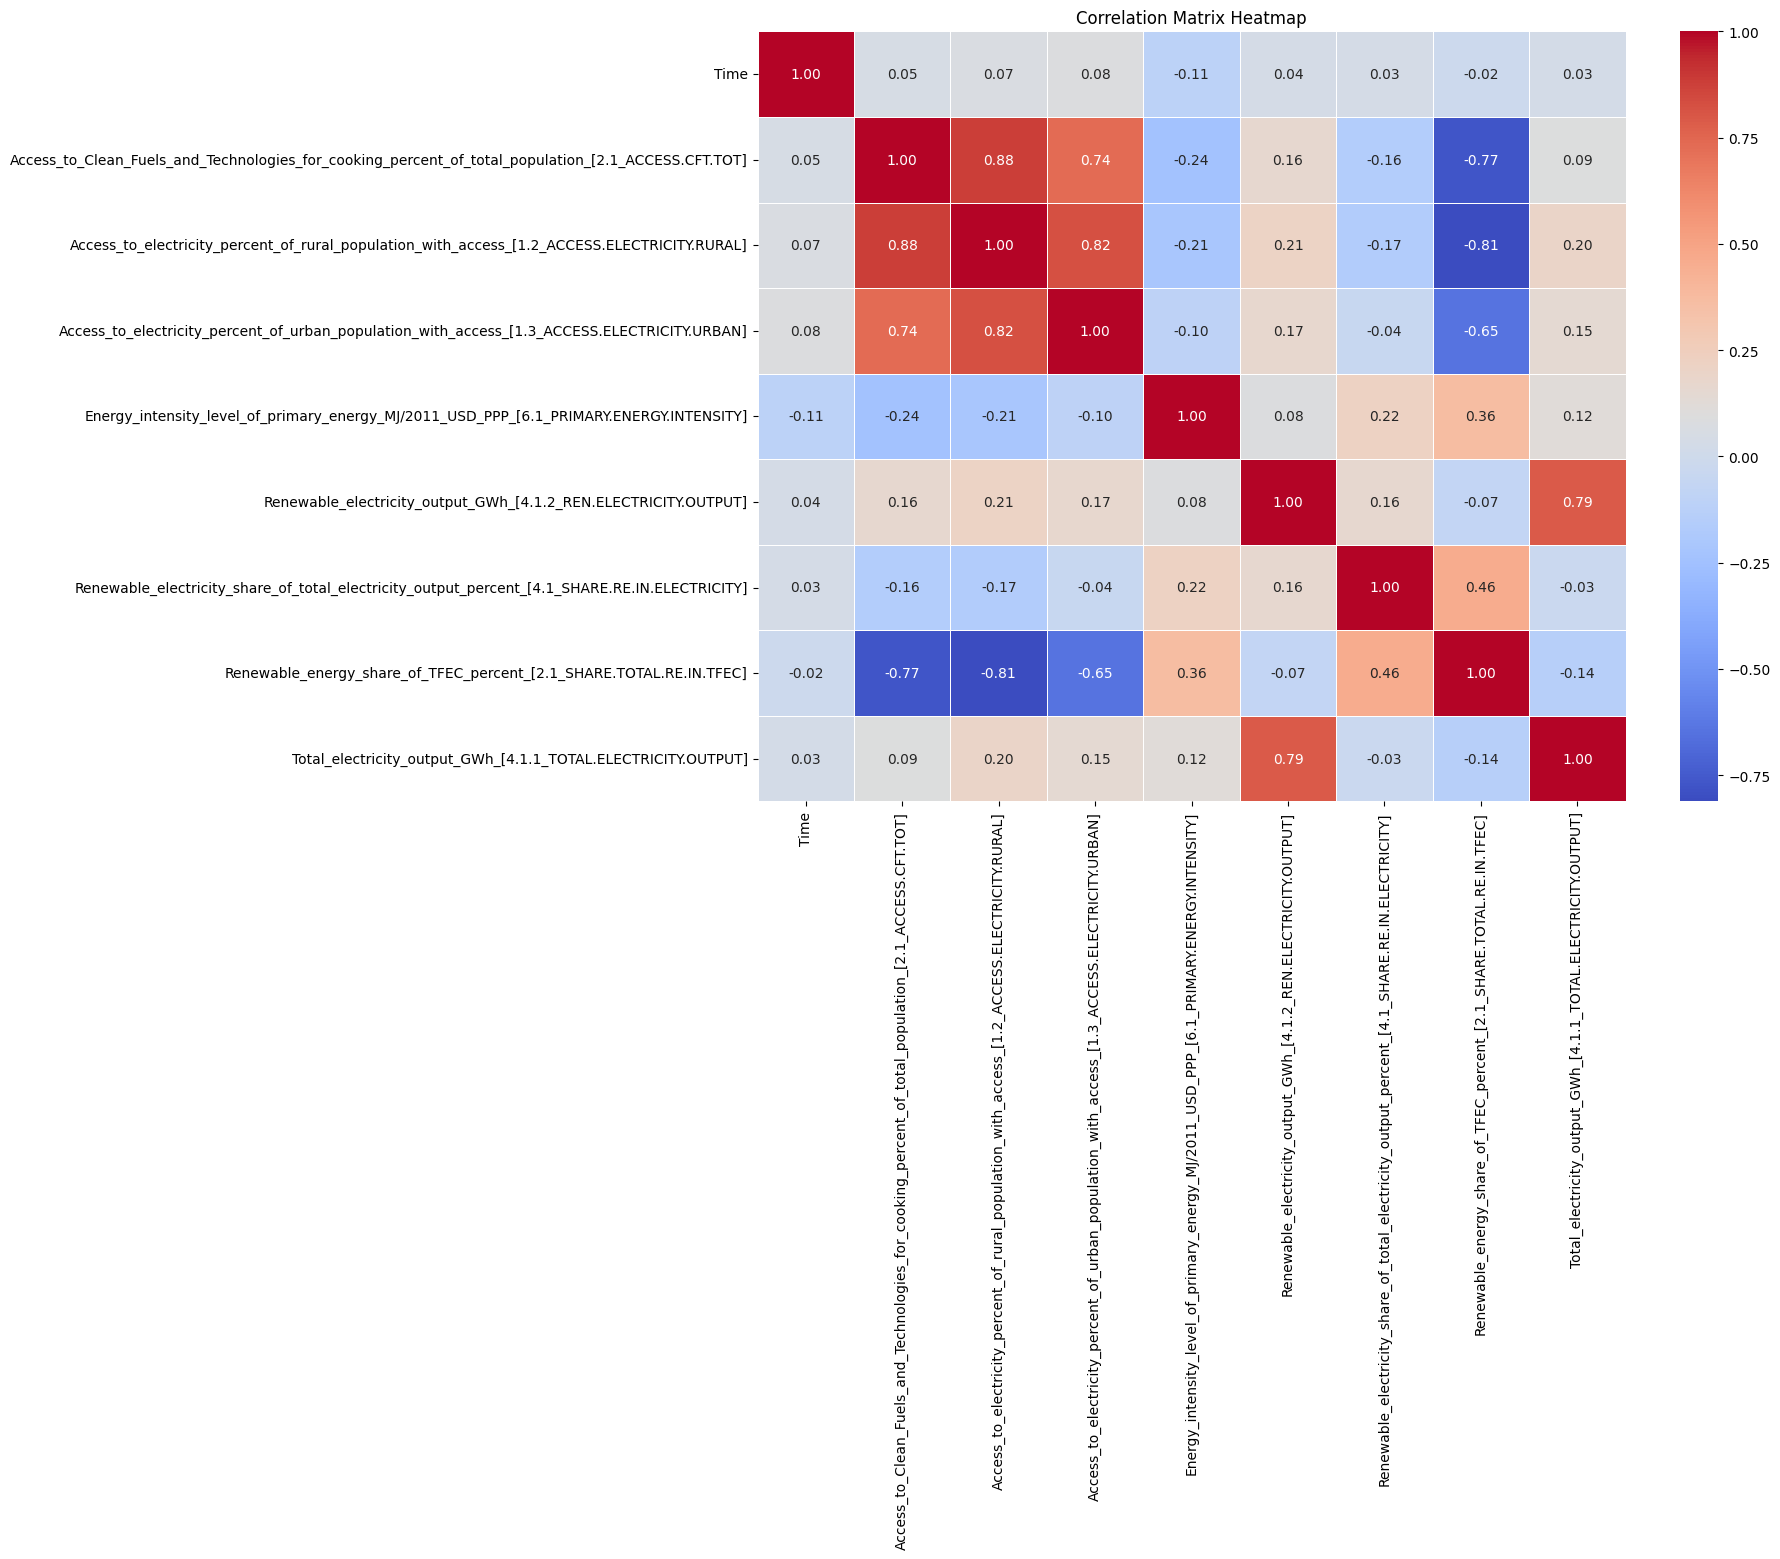


--- Variance Inflation Factor (VIF) Results ---
                                             Feature       VIF
3  Access_to_electricity_percent_of_rural_populat...  8.107985
2  Access_to_Clean_Fuels_and_Technologies_for_coo...  5.136527
8  Renewable_energy_share_of_TFEC_percent_[2.1_SH...  5.001468
4  Access_to_electricity_percent_of_urban_populat...  3.284498
9  Total_electricity_output_GWh_[4.1.1_TOTAL.ELEC...  3.220507
6  Renewable_electricity_output_GWh_[4.1.2_REN.EL...  3.219255
7  Renewable_electricity_share_of_total_electrici...  1.650531
5  Energy_intensity_level_of_primary_energy_MJ/20...  1.266889
1                                               Time  1.031146


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Load the dataset
# If running in Colab, ensure you upload the file first
file_path = '/content/reduced_energy_data.csv'
df = pd.read_csv(file_path)

# 2. Prepare Numeric Data
# We select only numeric columns and drop identifiers/categorical codes
numeric_df = df.select_dtypes(include=[np.number])

# Check for constant columns (VIF cannot be calculated if variance is 0)
constant_columns = [col for col in numeric_df.columns if numeric_df[col].nunique() <= 1]
if constant_columns:
    print(f"Dropping constant columns: {constant_columns}")
    numeric_df = numeric_df.drop(columns=constant_columns)

# 3. Generate Correlation Matrix Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

# 4. Calculate Variance Inflation Factor (VIF)
# We add a constant column for the intercept as required by statsmodels
X = add_constant(numeric_df)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Remove the 'const' row and sort by VIF
vif_results = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("\n--- Variance Inflation Factor (VIF) Results ---")
print(vif_results)

# Optional: Identify features with very high multicollinearity
high_vif = vif_results[vif_results['VIF'] > 10]
if not high_vif.empty:
    print("\nFeatures with VIF > 10 (High Multicollinearity):")
    print(high_vif['Feature'].tolist())

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def reduce_vif(df, threshold=10.0):
    """
    Iteratively removes features with VIF > threshold.
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    cols = numeric_df.columns.tolist()

    dropped_features = []

    while True:
        # Add a constant for the intercept
        X = add_constant(numeric_df[cols])

        # Calculate VIF for each feature
        vif_series = pd.Series(
            [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
            index=X.columns
        ).drop('const')

        max_vif = vif_series.max()

        if max_vif > threshold:
            feature_to_drop = vif_series.idxmax()
            print(f"Dropping '{feature_to_drop}' (VIF: {max_vif:.2f})")
            cols.remove(feature_to_drop)
            dropped_features.append(feature_to_drop)
        else:
            break

    # Reconstruct the dataframe with categorical columns and filtered numeric columns
    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    final_df = df[non_numeric + cols]

    print("\nReduction Complete.")
    print(f"Features Dropped: {dropped_features}")
    return final_df, vif_series

# 1. Load your dataset
df = pd.read_csv('/content/reduced_energy_data.csv')

# 2. Run the reduction function
reduced_df, final_vifs = reduce_vif(df, threshold=10.0)

# 3. View final VIFs
print("\nFinal VIF Values:")
print(final_vifs)

# 4. Save the new dataset
reduced_df.to_csv('reduced_energy_data.csv', index=False)
print("\nReduced dataset saved as 'reduced_energy_data.csv'")


Reduction Complete.
Features Dropped: []

Final VIF Values:
Time                                                                                                   1.031146
Access_to_Clean_Fuels_and_Technologies_for_cooking_percent_of_total_population_[2.1_ACCESS.CFT.TOT]    5.136527
Access_to_electricity_percent_of_rural_population_with_access_[1.2_ACCESS.ELECTRICITY.RURAL]           8.107985
Access_to_electricity_percent_of_urban_population_with_access_[1.3_ACCESS.ELECTRICITY.URBAN]           3.284498
Energy_intensity_level_of_primary_energy_MJ/2011_USD_PPP_[6.1_PRIMARY.ENERGY.INTENSITY]                1.266889
Renewable_electricity_output_GWh_[4.1.2_REN.ELECTRICITY.OUTPUT]                                        3.219255
Renewable_electricity_share_of_total_electricity_output_percent_[4.1_SHARE.RE.IN.ELECTRICITY]          1.650531
Renewable_energy_share_of_TFEC_percent_[2.1_SHARE.TOTAL.RE.IN.TFEC]                                    5.001468
Total_electricity_output_GWh_[4.1.1_TOTAL.E

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define features (X) and target (y)
# Assuming 'Total_electricity_output_GWh_[4.1.1_TOTAL.ELECTRICITY.OUTPUT]' is our target variable for prediction
# Drop non-numeric and the target variable from features
features = reduced_df.select_dtypes(include=[np.number]).columns.tolist()
target_variable = 'Total_electricity_output_GWh_[4.1.1_TOTAL.ELECTRICITY.OUTPUT]'

if target_variable in features:
    features.remove(target_variable)

X = reduced_df[features]
y = reduced_df[target_variable]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Root Mean Squared Error (RMSE): 0.08
Mean Absolute Error (MAE): 0.04
R-squared (R2): 0.69


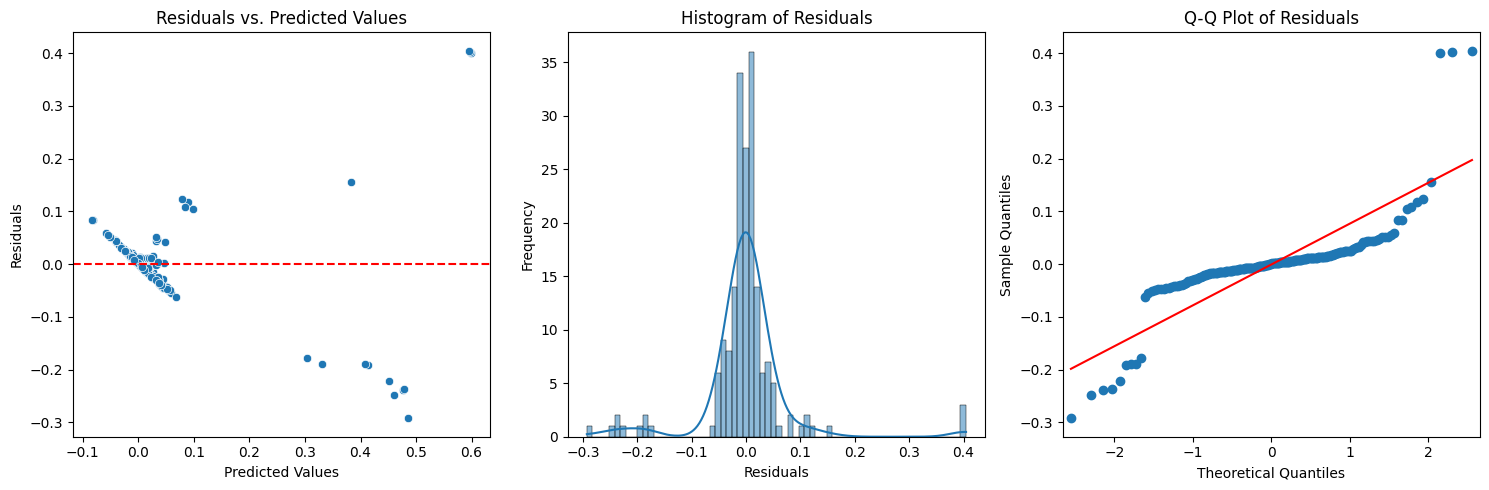

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(15, 5))

# Plot 1: Residuals vs. Predicted values
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')

# Plot 2: Histogram of Residuals
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')

# Plot 3: Q-Q plot of Residuals
plt.subplot(1, 3, 3)
qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [7]:
# Make predictions on the training set
y_train_pred = model.predict(X_train)

# Calculate R-squared for training set
r2_train = r2_score(y_train, y_train_pred)

print(f"R-squared (Training Set): {r2_train:.2f}")
print(f"R-squared (Test Set): {r2:.2f}")

if (r2_train - r2) > 0.1: # A common heuristic for significant difference
    print("\nWarning: The model might be overfitting as R-squared on the training set is significantly higher than on the test set.")
elif (r2_train - r2) < -0.1:
    print("\nNote: R-squared on the test set is slightly higher than on the training set, which can sometimes happen with random data splits but usually indicates a robust model.")
else:
    print("\nThe R-squared scores for the training and test sets are similar, suggesting that the model is not significantly overfitting.")

R-squared (Training Set): 0.69
R-squared (Test Set): 0.69

The R-squared scores for the training and test sets are similar, suggesting that the model is not significantly overfitting.
